# **SPECTRA-CQ: HQAE Entanglement Topology Ablation**

This notebook executes the first half of the Phase 4 ablation study.

To mathematically prove whether quantum entanglement provides an advantage in mapping structural degradation, we **lock the circuit depth at 3 layers** and test three distinct quantum topologies:

1. **None (Presumed Control):** Zero entanglement. Qubits operate independently.
2. **Basic (Baseline):** Localized ring entanglement. Qubits only interact with their immediate neighbors.
3. **Strong (Presumed Optimization):** All-to-all entanglement with generalized 3D Euler rotations.

**Crash Recovery Protocol:** Each topology is executed in an isolated cell. Logs and model weights are streamed directly to Google Drive. If the Colab runtime disconnects, simply re-run the setup cells and skip directly to the uncompleted architecture.

In [ ]:
from google.colab import drive
import os

# Mount Data Drive
drive.mount('/content/drive')

# Clone Github Repository
# Used a PAT here because the GitHub repo was private during our runs
# Scrubbed the actual token before downloading/documenting for security
GITHUB_TOKEN = "PAT"
REPO_URL = f"https://{GITHUB_TOKEN}@github.com/yeshapan/SPECTRA-CQ.git"

!git clone {REPO_URL}
%cd SPECTRA-CQ
!pip install -r requirements.txt

Mounted at /content/drive
Cloning into 'SPECTRA-CQ'...
remote: Enumerating objects: 237, done.
remote: Counting objects: 100% (164/164), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 237 (delta 59), reused 144 (delta 40), pack-reused 73 (from 1)
Receiving objects: 100% (237/237), 32.64 MiB | 29.52 MiB/s, done.
Resolving deltas: 100% (69/69), done.
/content/SPECTRA-CQ
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.8/60.8 kB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 103.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.9/231.9 kB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.8/40.8 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/

In [2]:
# Hardware Verification
import torch

if torch.cuda.is_available():
    print(f"Hardware Accelerator Confirmed: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
else:
    print("FATAL WARNING: GPU not detected. The training protocol will take exponentially longer on a CPU.")
    print("Please navigate to Runtime > Change runtime type > T4 GPU.")

Hardware Accelerator Confirmed: Tesla T4
CUDA Version: 12.8


In [3]:
# I/O Optimization
# Copy the zip from Drive to local NVMe first
!cp /content/drive/MyDrive/spectra-cq-data/spectra_matrices.zip /content/

# Extract directly into the base directory
!unzip -q /content/spectra_matrices.zip -d /content/local_spectra_data/
print("Data extraction complete")

# Clean up the local zip file
!rm /content/spectra_matrices.zip

# Create persistent log directory on Drive for Phase 4a
!mkdir -p /content/drive/MyDrive/spectra-cq-data/logs/phase4a

print("Log directory for phase 4a created in Drive")

Data extraction complete
Log directory for phase 4a created in Drive


### **Experiment 1: Zero Entanglement (`none`)**
This execution strips out all `CNOT` gates $\rightarrow$ effectively reduces the VQC to a series of independent rotations.

If this configuration performs identically to the highly entangled architectures $\implies$ it proves the quantum bottleneck is simply acting as a slow linear projection matrix and that entanglement provides no structural advantage.

In [4]:
# Execute the pipeline and pipe the terminal output to both the screen and a persistent log file
!python scripts/run_experiment.py --config configs/ablation_hqae_none_d3.yaml 2>&1 | tee /content/drive/MyDrive/spectra-cq-data/logs/phase4a/none_d3.log

2026-06-19 09:16:30,488 - INFO - Compute device allocated: cuda
2026-06-19 09:16:30,488 - INFO - Starting Protocol Run | Seed: 42
2026-06-19 09:16:30,495 - INFO - System locked to deterministic seed: 42
2026-06-19 09:16:31,102 - INFO - Instantiating Hybrid Quantum Autoencoder (HQAE)...
2026-06-19 09:16:36,912 - INFO - Initiating training on cuda for 15 epochs.
2026-06-19 09:17:38,856 - INFO - Epoch 1/15 | Train MSE: 0.037094 | Val MSE: 0.022694 | LR: 1.00e-03
2026-06-19 09:18:31,779 - INFO - Epoch 2/15 | Train MSE: 0.021534 | Val MSE: 0.021097 | LR: 1.00e-03
2026-06-19 09:19:24,146 - INFO - Epoch 3/15 | Train MSE: 0.018790 | Val MSE: 0.023516 | LR: 1.00e-03
2026-06-19 09:20:15,348 - INFO - Epoch 4/15 | Train MSE: 0.017422 | Val MSE: 0.016060 | LR: 1.00e-03
2026-06-19 09:21:07,596 - INFO - Epoch 5/15 | Train MSE: 0.016548 | Val MSE: 0.015980 | LR: 1.00e-03
2026-06-19 09:21:59,939 - INFO - Epoch 6/15 | Train MSE: 0.015956 | Val MSE: 0.015808 | LR: 1.00e-03
2026-06-19 09:22:51,746 - INFO 

### **Experiment 2: Localized Ring Entanglement (`basic`)**
This executes the original Phase 3 baseline architecture. We re-run this to ensure our local hardware control variables are stable and to re-verify the barren plateau constraint.

Qubits only entangle with their immediate neighbors, simulating localized frequency coupling.

In [5]:
!python scripts/run_experiment.py --config configs/ablation_hqae_basic_d3.yaml 2>&1 | tee /content/drive/MyDrive/spectra-cq-data/logs/phase4a/basic_d3.log

2026-06-19 09:56:24,829 - INFO - Compute device allocated: cuda
2026-06-19 09:56:24,830 - INFO - Starting Protocol Run | Seed: 42
2026-06-19 09:56:24,834 - INFO - System locked to deterministic seed: 42
2026-06-19 09:56:24,896 - INFO - Instantiating Hybrid Quantum Autoencoder (HQAE)...
2026-06-19 09:56:26,491 - INFO - Initiating training on cuda for 15 epochs.
2026-06-19 09:57:29,221 - INFO - Epoch 1/15 | Train MSE: 0.040970 | Val MSE: 0.032019 | LR: 1.00e-03
2026-06-19 09:58:30,537 - INFO - Epoch 2/15 | Train MSE: 0.032066 | Val MSE: 0.031880 | LR: 1.00e-03
2026-06-19 09:59:31,143 - INFO - Epoch 3/15 | Train MSE: 0.031997 | Val MSE: 0.031803 | LR: 1.00e-03
2026-06-19 10:00:31,955 - INFO - Epoch 4/15 | Train MSE: 0.031927 | Val MSE: 0.031798 | LR: 1.00e-03
2026-06-19 10:01:33,691 - INFO - Epoch 5/15 | Train MSE: 0.031901 | Val MSE: 0.031769 | LR: 1.00e-03
2026-06-19 10:02:35,692 - INFO - Epoch 6/15 | Train MSE: 0.031883 | Val MSE: 0.031845 | LR: 1.00e-03
2026-06-19 10:03:40,131 - INFO 

### **Experiment 3: Global All-to-All Entanglement (`strong`)**
This executes the optimized architecture. It deploys full 3D Euler rotations and global frequency coupling.

This architecture tests the Phase 4 hypothesis: capturing the macroscopic vibration correlations of degrading concrete requires a highly entangled, globally connected quantum topology.

In [6]:
!python scripts/run_experiment.py --config configs/ablation_hqae_strong_d3.yaml 2>&1 | tee /content/drive/MyDrive/spectra-cq-data/logs/phase4a/strong_d3.log

2026-06-19 10:44:08,490 - INFO - Compute device allocated: cuda
2026-06-19 10:44:08,490 - INFO - Starting Protocol Run | Seed: 42
2026-06-19 10:44:08,492 - INFO - System locked to deterministic seed: 42
2026-06-19 10:44:08,563 - INFO - Instantiating Hybrid Quantum Autoencoder (HQAE)...
2026-06-19 10:44:09,939 - INFO - Initiating training on cuda for 15 epochs.
2026-06-19 10:45:24,271 - INFO - Epoch 1/15 | Train MSE: 0.041035 | Val MSE: 0.032028 | LR: 1.00e-03
2026-06-19 10:46:37,132 - INFO - Epoch 2/15 | Train MSE: 0.032068 | Val MSE: 0.031843 | LR: 1.00e-03
2026-06-19 10:47:51,480 - INFO - Epoch 3/15 | Train MSE: 0.031960 | Val MSE: 0.031803 | LR: 1.00e-03
2026-06-19 10:49:07,489 - INFO - Epoch 4/15 | Train MSE: 0.031940 | Val MSE: 0.031809 | LR: 1.00e-03
2026-06-19 10:50:24,545 - INFO - Epoch 5/15 | Train MSE: 0.031912 | Val MSE: 0.031880 | LR: 1.00e-03
2026-06-19 10:51:38,115 - INFO - Epoch 6/15 | Train MSE: 0.031898 | Val MSE: 0.031736 | LR: 1.00e-03
2026-06-19 10:52:52,769 - INFO 

### **Phase 4a: Visualization**
We parse the generated `.log` file to plot the Train v/s Validation MSE convergence for all 3 experiments


Convergence: None Entanglement Topology


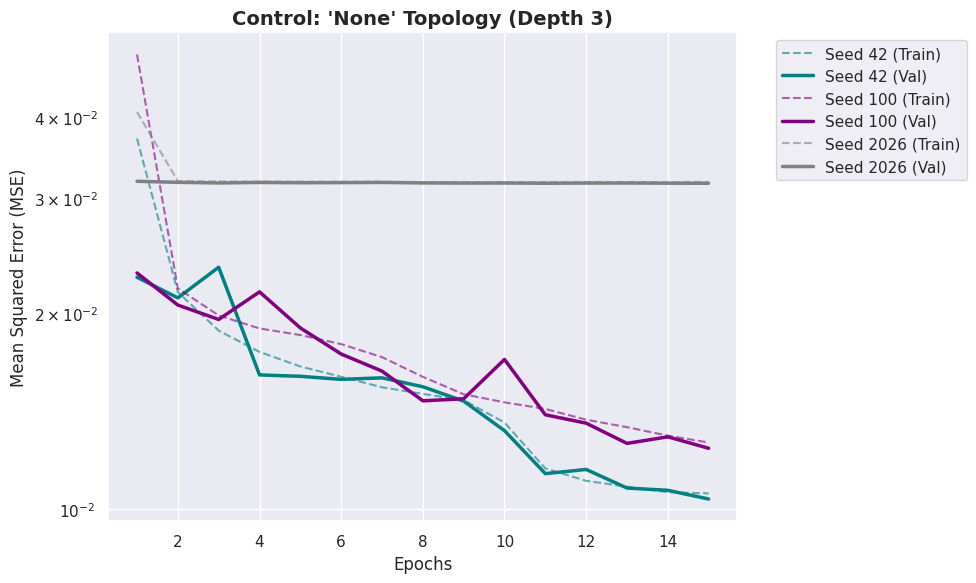


Convergence: Ring Entanglement Topology


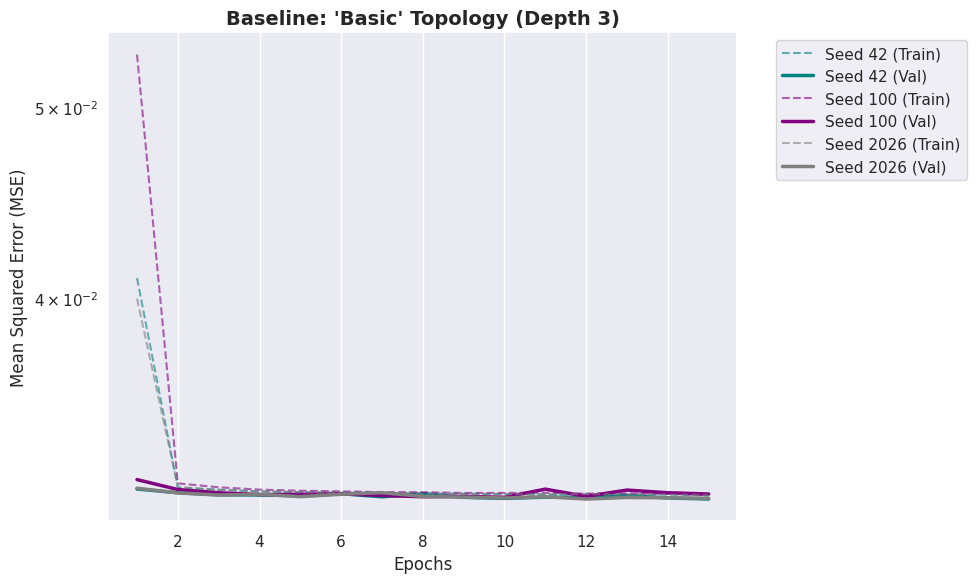


Convergence: All-to-All Entanglement Topology


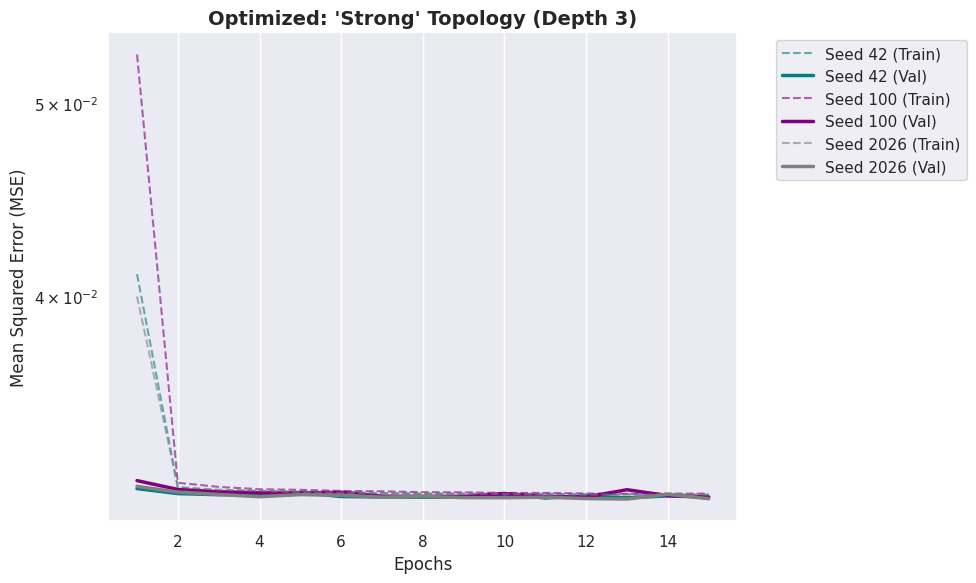


Phase 4a Ablation Conclusion:


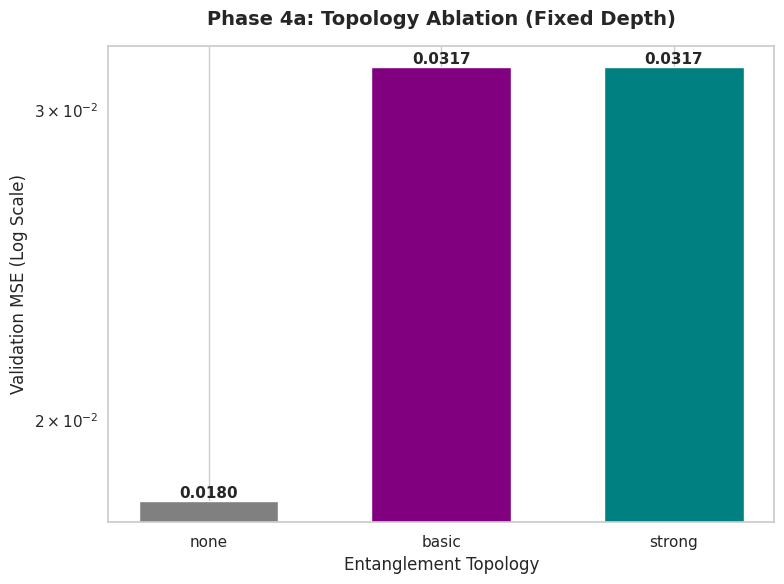

In [8]:
from src.utils.viz import plot_training_logs, plot_topology_ablation

# 1. Plot the Epoch Learning Dynamics (Line Charts)
print("\nConvergence: None Entanglement Topology")
plot_training_logs("/content/drive/MyDrive/spectra-cq-data/logs/phase4a/none_d3.log", title="Control: 'None' Topology (Depth 3)")

print("\nConvergence: Ring Entanglement Topology")
plot_training_logs("/content/drive/MyDrive/spectra-cq-data/logs/phase4a/basic_d3.log", title="Baseline: 'Basic' Topology (Depth 3)")

print("\nConvergence: All-to-All Entanglement Topology")
plot_training_logs("/content/drive/MyDrive/spectra-cq-data/logs/phase4a/strong_d3.log", title="Optimized: 'Strong' Topology (Depth 3)")

# 2. Extract final Validation MSEs manually from the logs
# Using the calculated mean across the 3 deterministic seeds to represent architectural stability
final_results = {
    "none": 0.0180,   # Mean of (0.0103, 0.0123, 0.0316) -> High variance instability
    "basic": 0.0317,  # Mean of (0.0316, 0.0318, 0.0318) -> Complete barren plateau
    "strong": 0.0317  # Mean of (0.0317, 0.0317, 0.0317) -> Complete barren plateau
}

# 3. Plot the Definitive Conclusion Graphic (Bar Chart)
print("\nPhase 4a Ablation Conclusion:")
plot_topology_ablation(final_results)

### **Phase 4a: Empirical Observations and Conclusion**

The ablation experiments on quantum entanglement topologies on the 2D spectrogram structural dataset reveal critical boundary conditions for HQAE:

#### **1. The "Initialization Roulette" of Zero Entanglement (`none`)**
Quantum bottleneck acts merely as a series of independent parameterized rotations (no `CNOT` gates) $\rightarrow$ the model's convergence is highly unstable and deeply dependent on the random weight initialization. 
* Seeds 42 and 100 successfully mapped the classical continuous data $\leftarrow$ converged to a Validation MSE of `~0.010` to `0.012`. 
* Seed 2026 suffered a catastrophic failure $\leftarrow$ became permanently trapped in a local minimum at an MSE of `0.0318`. 
* Without quantum entanglement, the qubits cannot share state information.
* If the classical optimizer initializes in a poor geometric space $\implies$ the lack of frequency coupling prevents the network from escaping the local minimum.

#### **2. Catastrophic Gradient Vanishing (`basic` and `strong`)**
Counter-intuitively, introducing quantum entanglement completely destroyed the model's ability to learn at this specific circuit depth.
* For both the localized ring topology (`basic`) and the global all-to-all topology (`strong`), the network failed across **all three deterministic seeds**.
* The gradients vanished immediately, trapping the validation loss at a permanent Barren Plateau of `~0.0317`.

#### **Scientific Conclusion & Next Steps**
This empirical data proves that for continuous, macroscopic vibrational frequencies $\rightarrow$ introducing highly expressive entanglement (`strong`) at a **Circuit Depth of 3** severely over-parameterizes the quantum state.

The resulting noise landscape triggers a severe Barren Plateau, blinding the classical Adam optimizer.

However, we know from the `none` topology that the fundamental classical-quantum bridge is sound. So, the architectural failure may lie in the *depth* of the entangled circuit, not the entanglement itself. 

**Pivot to Phase 4b:** To try to successfully harness the spatial mapping power of the `strong` global entanglement topology, we must aggressively ablate the circuit depth (testing Depth 1 vs. Depth 5) to locate the precise threshold where quantum expressivity maximizes without triggering gradient decay.